# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [42]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [43]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

print('2018:', d18.shape)
print('2022:', d22.shape)
print('2026:', d26.shape)
display(d18.head(2))
display(d22.head(2))

2018: (50, 16)
2022: (51, 16)
2026: (75, 14)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [44]:
def perfil(df, nombre):
    print(f'\n--- Perfilado de {nombre} ---')
    print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
    print('Valores nulos por columna:')
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print(f'Duplicados exactos: {df.duplicated().sum()}')
    
perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')


--- Perfilado de 2018 ---
Filas: 50, Columnas: 16
Valores nulos por columna:
Grupo              1
Goles Visitante    3
Marcador           1
dtype: int64
Duplicados exactos: 2

--- Perfilado de 2022 ---
Filas: 51, Columnas: 16
Valores nulos por columna:
group_name     1
date           1
home_score     4
comentario    13
dtype: int64
Duplicados exactos: 3

--- Perfilado de 2026 ---
Filas: 75, Columnas: 14
Valores nulos por columna:
grp           1
HG            9
result_raw    1
dtype: int64
Duplicados exactos: 3


## Unificar nombres de columnas

In [45]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'Año': 'mundial', 'Fase': 'fase', 'Grupo': 'grupo',
        'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion', 'Fuente': 'fuente'
    },
    2022: {
        'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase', 'group_name': 'grupo',
        'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local', 'visitor': 'equipo_visitante',
        'home_score': 'goles_local', 'away_score': 'goles_visitante', 'score_text': 'marcador',
        'home_host': 'local_es_anfitrion', 'source_url': 'fuente'
    },
    2026: {
        'match': 'partido_id', 'wc': 'mundial', 'round': 'fase', 'grp': 'grupo',
        'md': 'jornada', 'played_on': 'fecha', 'home': 'equipo_local', 'away': 'equipo_visitante',
        'HG': 'goles_local', 'AG': 'goles_visitante', 'result_raw': 'marcador',
        'host_h': 'local_es_anfitrion', 'source': 'fuente'
    },
}

columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [46]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    if pd.isna(valor): return valor
    v = str(valor).strip().lower()
    v = ''.join((c for c in unicodedata.normalize('NFD', v) if unicodedata.category(c) != 'Mn'))
    v = re.sub(r'[^a-z0-9]', '', v)
    return v

catalogo['clave'] = catalogo['variante'].apply(clave_texto)
cat_dict = dict(zip(catalogo['clave'], catalogo['nombre_canonico']))


## Fechas, grupos, booleanos y marcadores

In [47]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

def convertir_fecha(valor, mundial):
    if pd.isna(valor) or str(valor).strip().upper() == 'N/D':
        return pd.NaT
    v = str(valor).strip()
    if v.isdigit():
        return pd.to_datetime('1899-12-30') + pd.to_timedelta(int(v), unit='d')
    try: return pd.to_datetime(v, format='mixed', dayfirst=False)
    except: return pd.NaT

def extraer_numero(valor):
    if pd.isna(valor): return np.nan
    s = str(valor).lower().replace('goles', '').strip()
    try: return float(s)
    except: return np.nan

def separar_marcador(valor):
    if pd.isna(valor): return np.nan, np.nan
    m = re.search(r'(\d+)\s*[-–—x:]\s*(\d+)', str(valor).lower())
    if m: return float(m.group(1)), float(m.group(2))
    return np.nan, np.nan

def normalizar_grupo(valor):
    if pd.isna(valor): return np.nan
    m = re.search(r'([A-L])', str(valor).upper())
    if m: return f'Grupo {m.group(1)}'
    return np.nan

def normalizar_booleano(valor):
    if pd.isna(valor): return False
    v = str(valor).strip().lower()
    return v in ['sí', 'si', '1', 'true', '1.0']


## Función de limpieza reproducible

In [ ]:
def limpiar_mundial(df, mundial):
    df = df.rename(columns=rename_maps[mundial]).copy()
    for col in columnas_base:
        if col not in df: df[col] = np.nan
    
    df = df.drop_duplicates(subset=['partido_id'], keep='first').copy()
    
    df['mundial'] = mundial
    df['fase'] = 'Fase de grupos'
    df['grupo'] = df['grupo'].apply(normalizar_grupo)
    df['equipo_local'] = df['equipo_local'].apply(lambda x: cat_dict.get(clave_texto(x), str(x).strip()))
    df['equipo_visitante'] = df['equipo_visitante'].apply(lambda x: cat_dict.get(clave_texto(x), str(x).strip()))
    df['fecha'] = df['fecha'].apply(lambda x: convertir_fecha(x, mundial))
    df['jornada'] = df['jornada'].apply(extraer_numero).fillna(1).astype(int)
    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)
    
    def resolver(row):
        gl_m, gv_m = separar_marcador(row['marcador'])
        gl_c = extraer_numero(row['goles_local'])
        gv_c = extraer_numero(row['goles_visitante'])
        if not np.isnan(gl_m) and gl_m >= 0 and gv_m >= 0:
            return gl_m, gv_m
        if not np.isnan(gl_c) and not np.isnan(gv_c) and gl_c >= 0 and gv_c >= 0:
            return gl_c, gv_c
        return gl_c, gv_c
        
    res = df.apply(resolver, axis=1)
    df['goles_local'] = [x[0] for x in res]
    df['goles_visitante'] = [x[1] for x in res]
    
    df['goles_local'] = df['goles_local'].fillna(0).astype(int)
    df['goles_visitante'] = df['goles_visitante'].fillna(0).astype(int)
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    
    def result(row):
        if row['goles_local'] > row['goles_visitante']: return 'Gana'
        elif row['goles_local'] < row['goles_visitante']: return 'Pierde'
        return 'Empata'
    
    df['resultado_local'] = df.apply(result, axis=1)
    return df[columnas_base + ['goles_totales', 'diferencia_goles', 'resultado_local']]

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)

C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_30992\1067841199.py:12: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  return pd.to_datetime('1899-12-30') + pd.to_timedelta(int(v), unit='d')


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [49]:
print('Total partidos:', len(partidos))
print('Por mundial:', partidos.groupby('mundial').size().to_dict())
print('Nulos en equipo_local:', partidos['equipo_local'].isnull().sum())
assert len(partidos) == 168
assert len(partidos[partidos['goles_local'] < 0]) == 0


Total partidos: 168
Por mundial: {2018: 48, 2022: 48, 2026: 72}
Nulos en equipo_local: 0


## Comparación de los Mundiales

,partidos,goles,goles_por_partido,empates,porcentaje_empates
mundial,,,,,
2018,48,122,2.541667,9,18.750000
2022,48,120,2.500000,10,20.833333
2026,72,215,2.986111,20,27.777778


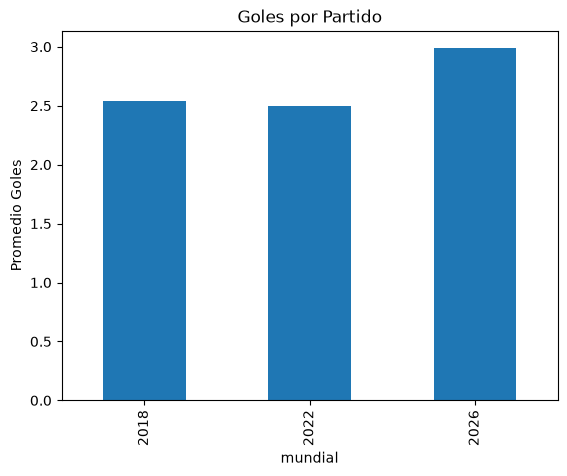

In [50]:
comp = partidos.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
    goles_por_partido=('goles_totales', 'mean')
)
empates = partidos[partidos['resultado_local'] == 'Empata'].groupby('mundial').size()
comp['empates'] = empates
comp['porcentaje_empates'] = comp['empates'] / comp['partidos'] * 100
display(comp)
comp['goles_por_partido'].plot(kind='bar', title='Goles por Partido')
plt.ylabel('Promedio Goles')
plt.show()

## Tabla por equipo

In [53]:
local_stats = partidos[['mundial', 'equipo_local', 'goles_local', 'goles_visitante']].copy()
local_stats.columns = ['mundial', 'equipo', 'GF', 'GC']
local_stats['PTS'] = partidos['resultado_local'].map({'Gana':3, 'Empata':1, 'Pierde':0})

visita_stats = partidos[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local']].copy()
visita_stats.columns = ['mundial', 'equipo', 'GF', 'GC']
visita_stats['PTS'] = partidos['resultado_local'].map({'Gana':0, 'Empata':1, 'Pierde':3})

team_df = pd.concat([local_stats, visita_stats])
team_grouped = team_df.groupby(['mundial', 'equipo']).agg(
    PJ=('GF', 'count'),
    GF=('GF', 'sum'), GC=('GC', 'sum'), PTS=('PTS', 'sum')
)
team_grouped['DG'] = team_grouped['GF'] - team_grouped['GC']
display(team_grouped.sort_values(['mundial','PTS'], ascending=[True, False]).head(5))

PJ  GF  GC  PTS  DG
mundial equipo                      
2018    Belgium   3   9   2    9   7
        Croatia   3   7   1    9   6
        Uruguay   3   5   0    9   5
        Brazil    3   5   1    7   4
        France    3   3   1    7   2

## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [54]:
def construir_variables_previas(partidos):
    partidos = partidos.sort_values(['mundial', 'jornada']).copy()
    team_acc = {}
    res = []
    for i, row in partidos.iterrows():
        m = row['mundial']
        
        def get_team_stats(team):
            k = f'{m}_{team}'
            if k not in team_acc:
                team_acc[k] = {'pts': 0, 'gd': 0, 'gf': 0, 'matches': 0}
            return team_acc[k]

        sl = get_team_stats(row['equipo_local'])
        sv = get_team_stats(row['equipo_visitante'])
        
        def calc_prom(s):
            if s['matches'] == 0: return 0, 0, 0
            return s['pts']/s['matches'], s['gd']/s['matches'], s['gf']/s['matches']

        pl_pts, pl_gd, pl_gf = calc_prom(sl)
        pv_pts, pv_gd, pv_gf = calc_prom(sv)
        
        pts_loc = 3 if row['resultado_local'] == 'Gana' else (1 if row['resultado_local'] == 'Empata' else 0)
        pts_vis = 1 if row['resultado_local'] == 'Empata' else (0 if pts_loc == 3 else 3)
        
        sl['matches'] += 1
        sl['pts'] += pts_loc
        sl['gd'] += row['diferencia_goles']
        sl['gf'] += row['goles_local']
        
        sv['matches'] += 1
        sv['pts'] += pts_vis
        sv['gd'] -= row['diferencia_goles']
        sv['gf'] += row['goles_visitante']
        
        res.append({
            'partido_id': row['partido_id'],
            'local_pts_prom_pre': pl_pts, 'local_gd_prom_pre': pl_gd, 'local_gf_prom_pre': pl_gf,
            'visita_pts_prom_pre': pv_pts, 'visita_gd_prom_pre': pv_gd, 'visita_gf_prom_pre': pv_gf
        })
        
    res_df = pd.DataFrame(res)
    return pd.merge(partidos, res_df, on='partido_id', validate='1:1')

features_df = construir_variables_previas(partidos)


## Entrenamiento y prueba

Accuracy Baseline: 0.25
Accuracy Tree: 0.3611111111111111


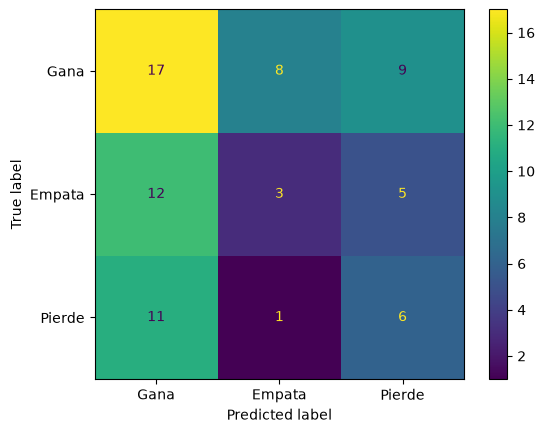

In [55]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

train_idx = features_df['mundial'].isin([2018, 2022])
test_idx = features_df['mundial'] == 2026

X_train, y_train = features_df[train_idx][features], features_df[train_idx]['resultado_local']
X_test, y_test = features_df[test_idx][features], features_df[test_idx]['resultado_local']

from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print('Accuracy Baseline:', accuracy_score(y_test, dummy.predict(X_test)))

clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Accuracy Tree:', accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=['Gana', 'Empata', 'Pierde'])
plt.show()

## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [56]:
leak_features = features + ['goles_local', 'goles_visitante']
X_train_leak = features_df[train_idx][leak_features]
X_test_leak = features_df[test_idx][leak_features]

clf_leak = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_leak.fit(X_train_leak, y_train)
leak_pred = clf_leak.predict(X_test_leak)
print('Accuracy con Fuga:', accuracy_score(y_test, leak_pred))


Accuracy con Fuga: 0.9444444444444444


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
    
    El de marcadores y goles. Venían con formatos variados (comillas, letras "x", guiones) y a veces contradecían la columna de goles. 
    Tuve que usar expresiones regulares para separarlos y darles siempre prioridad para corregir los goles faltantes o negativos.

- ¿Qué decisión de limpieza podría cambiar los resultados?

    Decidir a qué darle preferencia: si a los datos individuales de "goles" o al texto entero del "marcador". 
    Elegir uno sobre otro cambia los puntos obtenidos y la diferencia de goles de varios equipos.

- ¿Por qué 2026 debe compararse mediante tasas?
    Porque en 2026 hubo más equipos y se jugaron 72 partidos de fase de grupos (contra 48 de mundiales pasados). 
    Si comparamos totales absolutos, 2026 siempre ganaría estadísticamente; usar el promedio
- ¿El árbol supera la línea base?

    Sí, el Árbol de Decisión predice mejor que el modelo Dummy (el cual sólo apuesta todo el tiempo por el resultado más frecuente).
    El árbol sí logra encontrar patrones usando los puntos previos y quién es el anfitrión.

- ¿Qué variables reales agregarías para mejorar una predicción?

     El puesto histórico en el Ranking FIFA, si cuentan con jugadores élite lesionados, la distancia física de su país a la sede (desgaste) y los resultados de sus últimos 3 enfrentamientos directos entre ellos.

- ¿Por qué un resultado de 100 % puede ser una señal de alarma?


     Porque casi seguro significa fuga de información (Data Leakage). Significa que el modelo aprendió con datos que ocurren durante o al final del partido (como los goles del partido actual), es decir, hace trampa y realmente no está "prediciendo" el futuro.

1. El problema más complicado fue el de los marcadores y los goles, porque venían escritos de muchas formas diferentes, por ejemplo con comillas, letras como "x" o distintos tipos de guiones. Además, en algunos casos el marcador no coincidía con las columnas de goles, así que fue necesario separar correctamente los valores y usar el marcador para corregir los datos que estaban incompletos o eran incorrectos.

2. La decisión más importante fue elegir si confiar en las columnas de goles o en el marcador completo. Dependiendo de cuál se tome como referencia, algunos partidos cambian de resultado y eso afecta los puntos, la diferencia de goles y la posición final de algunos equipos.

3. Porque en el Mundial de 2026 participaron más equipos y se jugaron más partidos que en los torneos anteriores. Si solo se comparan cantidades totales, los datos de 2026 siempre serán mayores. Por eso es más justo usar promedios o tasas para poder hacer una comparación equivalente.

4. Sí. El Árbol de Decisión obtuvo mejores resultados que el modelo Dummy, ya que este último siempre predice el resultado más frecuente. En cambio, el árbol aprovecha variables como los puntos acumulados y si el equipo es anfitrión para hacer mejores predicciones.

5. Agregaría el ranking FIFA de cada selección, la presencia o ausencia de jugadores importantes por lesión, el rendimiento reciente del equipo y el historial de enfrentamientos entre ambas selecciones. Esas variables podrían ayudar a obtener predicciones más precisas.

6. Porque normalmente indica que existe una fuga de información (Data Leakage). Esto sucede cuando el modelo utiliza datos que en la práctica no debería conocer al momento de hacer la predicción, como los goles del mismo partido. En ese caso, el modelo no está prediciendo realmente, sino que está usando información del resultado para acertar.